# EM reference audit — the diagnostics that exonerate (or convict) a FEM cross-validation reference

**Why this notebook exists.** The 2026-07-03 planar-VIM motor / eddy / induction campaign found
**eight** bugs; every one lived in the *reference* or the *coupling layer* — zero in the shipped
charge Gram. Each hunt ended with a cheap, decisive diagnostic. This notebook **executes** those
diagnostics on minimal cases so the next disagreement starts here instead of in a rabbit hole.

**The audit ladder** (cheapest, most discriminating first):
1. solution-level scalar (e.g. volume-average M) before the derived observable;
2. evaluator invariance (Maxwell torque vs circle radius, …);
3. **drive-equivalence probe** — rerun the reference with the scatterer removed and compare the
   source field against the analytic one;
4. split tests (coil-only; no-scatterer channel self-tests must return ~0);
5. independent closed-form arbiter (`radia.analytical_formulas` is the catalog);
6. only then suspect the method under test.

Companion knowledge: MCP `hdiv_vim(topic="reference_audit")`; the trap catalog lives in
`bug_patterns_lookup(topic="validation")` (`fem-reference-coil-polygon-current-deficit`,
`truncation-ladder-frozen-edge`, `conjugate-potential-sign-branch-cut`,
`reference-secant-picard-oscillation`, `ngsolve-gettrafo-first-touch-garbage`).

In [1]:
import json, platform
import numpy as np
import matplotlib.pyplot as plt
import ngsolve as ng
from netgen.occ import WorkPlane, OCCGeometry, Glue
import radia
from radia.vim import PlanarDemagBody
import planar_vim_motor_helpers as H

MU0 = 4e-7*np.pi
RESULTS = {"radia_version": radia.__version__, "platform": platform.platform()}
print("radia", radia.__version__)

radia 4.95.5


## D1. Coil-disk polygon current deficit — and the drive-equivalence probe

A FEM reference that models coil wires as uniform-J disks (`J = I / (pi r^2)`) silently
under-carries current when the disk is left **uncurved**: netgen meshes the circle as an
inscribed polygon whose segment count comes from *curvature heuristics*, not from the volume
`maxh` — so **refinement ladders never reveal it**. The killer diagnostic is the
**drive-equivalence probe**: remove the scatterer and compare the FEM source field at interior
probes against the analytic line-current field. A *uniform* percentage deficit at every probe is
a source-amplitude bug; a position-dependent deviation is boundary truncation.

In [2]:
# (i) the deficit itself: measured disk area vs pi r^2, uncurved vs curved
r_disk = H.WIRE_R
disk = WorkPlane().Circle(0.3, 0.2, r_disk).Face()
disk.faces.name = "disk"
box = WorkPlane().RectangleC(2, 2).Face()
air = box - WorkPlane().Circle(0.3, 0.2, r_disk).Face()
air.faces.name = "air"
mesh = ng.Mesh(OCCGeometry(Glue([air, disk]), dim=2).GenerateMesh(maxh=0.2))
with ng.TaskManager():
    A_uncurved = ng.Integrate(ng.CoefficientFunction(1.0), mesh, definedon=mesh.Materials("disk"))
    mesh.Curve(3)
    A_curved = ng.Integrate(ng.CoefficientFunction(1.0), mesh, definedon=mesh.Materials("disk"))
A_exact = np.pi*r_disk**2
d_unc = A_uncurved/A_exact - 1
d_cur = A_curved/A_exact - 1
print(f"disk area deficit: uncurved {d_unc:+.2%}   after mesh.Curve(3) {d_cur:+.2%}")
RESULTS["D1_area_deficit"] = {"uncurved": d_unc, "curved": d_cur}
assert d_unc < -0.02 and abs(d_cur) < 2e-3

# (ii) the drive-equivalence probe on the 6-coil stator (no rotor): uncurved + pi r^2 J
#      shows a UNIFORM ~-5% at every probe; curved + measured-area J fixes it.
def air_box_probe(curve, measured_area):
    W = H.wire_pos(45.0)
    box = WorkPlane().RectangleC(8, 8).Face()
    box.edges.name = "outer"
    coils = []
    for k, ((cx, cy), I) in enumerate(zip(W, H.I_K)):
        c = WorkPlane().Circle(cx, cy, H.WIRE_R).Face()
        c.faces.name = f"coil{k}"
        c.faces.maxh = 0.008
        coils.append(c)
    air = box
    for c in coils:
        air = air - c
    air.faces.name = "air"
    mesh = ng.Mesh(OCCGeometry(Glue([air] + coils), dim=2).GenerateMesh(maxh=0.5))
    if curve:
        mesh.Curve(3)
    fes = ng.H1(mesh, order=3, dirichlet="outer")
    u, v = fes.TnT()
    if measured_area:
        area = {k: ng.Integrate(ng.CoefficientFunction(1.0), mesh,
                                definedon=mesh.Materials(f"coil{k}")) for k in range(H.NW)}
    else:
        area = {k: np.pi*H.WIRE_R**2 for k in range(H.NW)}
    Jcf = mesh.MaterialCF({f"coil{k}": H.I_K[k]/area[k] for k in range(H.NW)}, default=0.0)
    a = ng.BilinearForm(fes)
    a += (1.0/MU0)*ng.grad(u)*ng.grad(v)*ng.dx
    a.Assemble()
    f = ng.LinearForm(fes)
    f += Jcf*v*ng.dx
    f.Assemble()
    gfA = ng.GridFunction(fes)
    gfA.vec.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky")*f.vec
    probes = np.array([(0.0, 0.0), (0.10, 0.05), (-0.10, 0.05), (0.11, -0.055)])
    Href = H.H_wires_np(probes, W)
    errs = []
    for (px, py), hr in zip(probes, Href):
        g = ng.grad(gfA)(mesh(px, py))
        Hf = np.array([g[1], -g[0]])/MU0
        errs.append(np.linalg.norm(Hf - hr)/np.linalg.norm(hr))
    return np.array(errs)

with ng.TaskManager():
    e_bad = air_box_probe(curve=False, measured_area=False)
    e_fix = air_box_probe(curve=True, measured_area=True)
print(f"drive-equivalence probe: uncurved + pi r^2 J -> {e_bad.mean():.2%} "
      f"(UNIFORM across probes: spread {e_bad.std():.2%}) ;  curved + measured-area J -> "
      f"{e_fix.max():.2%}")
RESULTS["D1_drive_probe"] = {"bad_mean": float(e_bad.mean()), "bad_spread": float(e_bad.std()),
                             "fixed_max": float(e_fix.max())}
assert e_bad.mean() > 0.03 and e_bad.std() < 0.01 and e_fix.max() < 0.01

disk area deficit: uncurved -5.37%   after mesh.Curve(3) +0.02%


drive-equivalence probe: uncurved + pi r^2 J -> 4.92% (UNIFORM across probes: spread 0.02%) ;  curved + measured-area J -> 0.41%


## D2. Conjugate potential: the gradient gate, and branch cuts on surrounding rings

The 2D pair for a magnetic charge `q` is `(psi, A) = (-q/(2 pi) ln r, +mu0 q/(2 pi) atan2(dy, dx))`
— the **sign** convention is locked by the gate `B(grad A) == mu0 H` (a `-mu0` here silently
*inverted* an iron→conductor coupling channel). And although the total `A` of a zero-net-charge
body is single-valued, the atan2 **formula** is discontinuous across each charge's `-x` ray:
evaluation sets that *surround* the body cross those cuts. The single-valued construction
integrates `dA/dphi = mu0 r H_r` (branch-free `H_at`) around the ring, anchored on the cut-free
`+x` axis; going the full `2 pi` must close exactly (Gauss, zero total charge).

gradient gate B(grad Az) == mu0 H_at: max rel 1.02e-10
atan2 formula: largest jump 72.0% of scale;  polar closure 4.02e-15


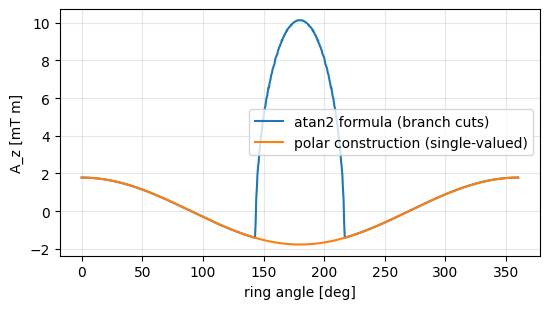

In [3]:
wp = WorkPlane().Circle(0, 0, 0.06).Face()
mesh = ng.Mesh(OCCGeometry(wp, dim=2).GenerateMesh(maxh=0.015))
with ng.TaskManager():
    body = PlanarDemagBody(mesh)
    m = body.solve_linear(999.0, body.project(ng.CoefficientFunction((0.0, -H.H0_IM))))

# (i) the gradient gate at exterior points
h = 1e-6
gate = []
for p in [(0.1, 0.02), (-0.08, 0.09), (0.0, -0.12)]:
    p = np.array(p)
    Bx = (body.Az_at(np.array([p + (0, h)]), m)[0] - body.Az_at(np.array([p - (0, h)]), m)[0])/(2*h)
    By = -(body.Az_at(np.array([p + (h, 0)]), m)[0] - body.Az_at(np.array([p - (h, 0)]), m)[0])/(2*h)
    Hm = MU0*body.H_at(np.array([p]), m)[0]
    gate.append(np.hypot(Bx - Hm[0], By - Hm[1])/np.linalg.norm(Hm))
print(f"gradient gate B(grad Az) == mu0 H_at: max rel {max(gate):.2e}")
RESULTS["D2_gradient_gate"] = float(max(gate))
assert max(gate) < 1e-5

# (ii) Az along a SURROUNDING circle: the atan2 formula vs the polar construction
Rring = 0.10
phi = np.linspace(0, 2*np.pi, 721)
P = np.stack([Rring*np.cos(phi), Rring*np.sin(phi)], axis=1)
A_atan2 = body.Az_at(P, m)
Hr = (body.H_at(P, m)*np.stack([np.cos(phi), np.sin(phi)], axis=1)).sum(axis=1)
A0 = body.Az_at(np.array([[Rring, 0.0]]), m)[0]
A_polar = A0 + MU0*Rring*np.concatenate([[0.0], np.cumsum(0.5*(Hr[1:]+Hr[:-1])*np.diff(phi))])
closure = abs(A_polar[-1] - A_polar[0])/np.abs(A_polar).max()
jump = np.abs(np.diff(A_atan2)).max()/np.abs(A_polar).max()
print(f"atan2 formula: largest jump {jump:.1%} of scale;  polar closure {closure:.2e}")
RESULTS["D2_ring"] = {"atan2_jump": float(jump), "polar_closure": float(closure)}
assert jump > 0.1 and closure < 1e-3
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(np.degrees(phi), A_atan2*1e3, label="atan2 formula (branch cuts)")
ax.plot(np.degrees(phi), A_polar*1e3, label="polar construction (single-valued)")
ax.set_xlabel("ring angle [deg]"); ax.set_ylabel("A_z [mT m]")
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout(); display(fig); plt.close(fig)

## D3. Finite-boundary image on a scattered dipole — matched in closed form, fixed by the exact open Robin

2D potentials have long tails: a truncation ladder that never moves *one* edge falsely
"converges" (`truncation-ladder-frozen-edge`). The magnetostatic twin is exact: a Dirichlet
`A = B0 r cos(theta)` at finite `R` reflects the scattered dipole `beta cos(theta)/r` of an iron
cylinder and suppresses it by **exactly** `1/(1 + beta_open/(B0 R^2))`. The n=1 exact open
boundary is the Robin relation `dA/dr + A/R = 2 B0 cos(theta)` — with it the finite domain hits
the open-space closed form directly.

In [4]:
a_ir, mu_r, B0 = 0.06, 1000.0, 0.05
chi = mu_r - 1.0
M_cm = chi*(B0/MU0)/(1.0 + chi/2.0)
beta_open = MU0*M_cm*a_ir**2/2.0

def solve_beta(REXT, robin):
    iron = WorkPlane().Circle(0, 0, a_ir).Face()
    iron.faces.name = "iron"
    outer = WorkPlane().Circle(0, 0, REXT).Face()
    outer.edges.name = "outer"
    air = outer - WorkPlane().Circle(0, 0, a_ir).Face()
    air.faces.name = "air"
    mesh = ng.Mesh(OCCGeometry(Glue([iron, air]), dim=2).GenerateMesh(maxh=REXT/16))
    mesh.Curve(4)
    fes = ng.H1(mesh, order=4, dirichlet=("" if robin else "outer"))
    u, v = fes.TnT()
    nu = mesh.MaterialCF({"iron": 1.0/(MU0*mu_r)}, default=1.0/MU0)
    a = ng.BilinearForm(fes)
    a += nu*ng.grad(u)*ng.grad(v)*ng.dx
    if robin:
        a += (1.0/MU0)/REXT*u*v*ng.ds(definedon=mesh.Boundaries("outer"))
    a.Assemble()
    gfA = ng.GridFunction(fes)
    if robin:
        f = ng.LinearForm(fes)
        f += (1.0/MU0)*2.0*B0*ng.cos(ng.atan2(ng.y, ng.x))*v*ng.ds(
            definedon=mesh.Boundaries("outer"))
        f.Assemble()
        gfA.vec.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky")*f.vec
    else:
        gfA.Set(B0*ng.x, definedon=mesh.Boundaries("outer"))
        r = (-1.0)*(a.mat*gfA.vec)
        upd = gfA.vec.CreateVector()
        upd.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky")*r
        gfA.vec.data += upd
    def cosproj(rr, nth=720):
        th = np.linspace(0, 2*np.pi, nth, endpoint=False)
        vals = np.array([gfA(mesh(rr*np.cos(t), rr*np.sin(t))) for t in th])
        return float((vals*np.cos(th)).sum()*(2*np.pi/nth)/np.pi)
    r1, r2 = 0.09, 0.14
    alpha, beta = np.linalg.solve(np.array([[r1, 1/r1], [r2, 1/r2]]),
                                  np.array([cosproj(r1), cosproj(r2)]))
    return beta

rows = []
with ng.TaskManager():
    for REXT in (0.2, 0.4):
        b = solve_beta(REXT, robin=False)
        b_img = beta_open/(1.0 + beta_open/(B0*REXT**2))
        rows.append({"REXT": REXT, "bc": "Dirichlet", "beta": b, "image_formula": b_img,
                     "rel_vs_image": abs(b - b_img)/b_img})
        print(f"Dirichlet R={REXT}: beta={b:.6e}  image formula={b_img:.6e}  "
              f"(match {abs(b-b_img)/b_img:.2%};  vs open {b/beta_open-1:+.1%})")
    b_rob = solve_beta(0.2, robin=True)
    print(f"Robin    R=0.2: beta={b_rob:.6e}  vs open closed form {beta_open:.6e}  "
          f"({abs(b_rob-beta_open)/beta_open:.2%})")
rows.append({"REXT": 0.2, "bc": "Robin-open", "beta": b_rob,
             "rel_vs_open": abs(b_rob - beta_open)/beta_open})
RESULTS["D3_image"] = rows
assert all(r["rel_vs_image"] < 0.02 for r in rows[:2])
assert abs(b_rob - beta_open)/beta_open < 0.005

Dirichlet R=0.2: beta=1.648349e-04  image formula=1.648349e-04  (match 0.00%;  vs open -8.2%)
Dirichlet R=0.4: beta=1.756941e-04  image formula=1.756951e-04  (match 0.00%;  vs open -2.2%)


Robin    R=0.2: beta=1.796404e-04  vs open closed form 1.796404e-04  (0.00%)


## D4. Reference nonlinearity: the secant-Picard plateau vs the exact Newton

At knee-level drive the salient-bar case's corner elements straddle the BH knee; the per-element
secant-`nu` successive substitution **plateaus** (`dA ~ 0.1`, never converging), and comparing
against that unconverged state produced a plausible-looking ~10% "disagreement". The saturating
law inverts in closed form, so the reference can be a **true Newton** on
`nu(|grad A|)` — quadratic convergence from a cold start.

secant Picard: after 40 iterations dA = 1.65e-02  (PLATEAU -- unconverged)
exact Newton : converged in 9 iterations (torque -4230.3 N m/m, ndof 6737)


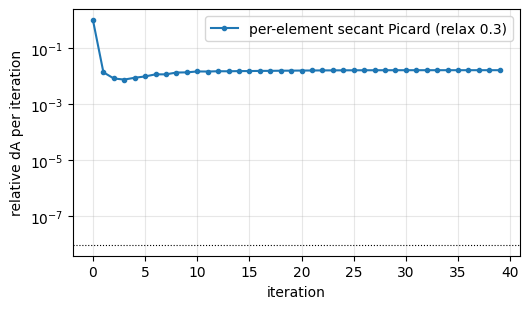

In [5]:
with ng.TaskManager():
    hist, ndof = H.fem_reference_bar_secant(45.0, nouter=40)
    T, _, it_newton = H.fem_reference_bar(45.0)
print(f"secant Picard: after {len(hist)} iterations dA = {hist[-1]:.2e}  (PLATEAU -- unconverged)")
print(f"exact Newton : converged in {it_newton} iterations (torque {T:.1f} N m/m, ndof {ndof})")
RESULTS["D4"] = {"secant_final_dA": float(hist[-1]), "newton_iters": int(it_newton)}
assert hist[-1] > 1e-3 and it_newton <= 15
fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.semilogy(hist, "o-", ms=3, label="per-element secant Picard (relax 0.3)")
ax.axhline(1e-8, color="k", ls=":", lw=0.8)
ax.set_xlabel("iteration"); ax.set_ylabel("relative dA per iteration")
ax.grid(alpha=0.3, which="both"); ax.legend(); fig.tight_layout(); display(fig); plt.close(fig)

## Summary

| Diagnostic | Catches | Bug pattern |
|---|---|---|
| measured area + drive-equivalence probe | source-amplitude deficits (uniform % at every probe) | `fem-reference-coil-polygon-current-deficit` |
| gradient gate + polar construction | sign/derivative errors and branch cuts in A-channels | `conjugate-potential-sign-branch-cut` |
| image closed form + exact open Robin | boundary-truncation bias (2D tails; frozen-edge ladders) | `truncation-ladder-frozen-edge` |
| fail-loud residual + closed-form Newton | unconverged nonlinear references | `reference-secant-picard-oscillation` |

Plus, always: solution-level scalars before derived observables; evaluator invariance sweeps;
split tests; `radia.analytical_formulas` as the closed-form arbiter; and the scalar-GetTrafo
determinism contract (`ngsolve-gettrafo-first-touch-garbage`). Full methodology: MCP
`hdiv_vim(topic="reference_audit")`.

In [6]:
print(json.dumps(RESULTS, indent=1, default=float)[:2500])

{
 "radia_version": "4.95.5",
 "platform": "Windows-2022Server-10.0.20348-SP0",
 "D1_area_deficit": {
  "uncurved": -0.053707702264697565,
  "curved": 0.0001781371699443035
 },
 "D1_drive_probe": {
  "bad_mean": 0.04916421437048195,
  "bad_spread": 0.00015926167937542056,
  "fixed_max": 0.004139914347217726
 },
 "D2_gradient_gate": 1.0214045694774622e-10,
 "D2_ring": {
  "atan2_jump": 0.720419911764476,
  "polar_closure": 4.0249170952912156e-15
 },
 "D3_image": [
  {
   "REXT": 0.2,
   "bc": "Dirichlet",
   "beta": 0.0001648348791998912,
   "image_formula": 0.00016483486263761446,
   "rel_vs_image": 1.0047799649770742e-07
  },
  {
   "REXT": 0.4,
   "bc": "Dirichlet",
   "beta": 0.00017569408674849543,
   "image_formula": 0.00017569511787020233,
   "rel_vs_image": 5.868812516805878e-06
  },
  {
   "REXT": 0.2,
   "bc": "Robin-open",
   "beta": 0.00017964037779660938,
   "rel_vs_open": 1.010699922201069e-07
  }
 ],
 "D4": {
  "secant_final_dA": 0.016505845873573247,
  "newton_iters": 9
